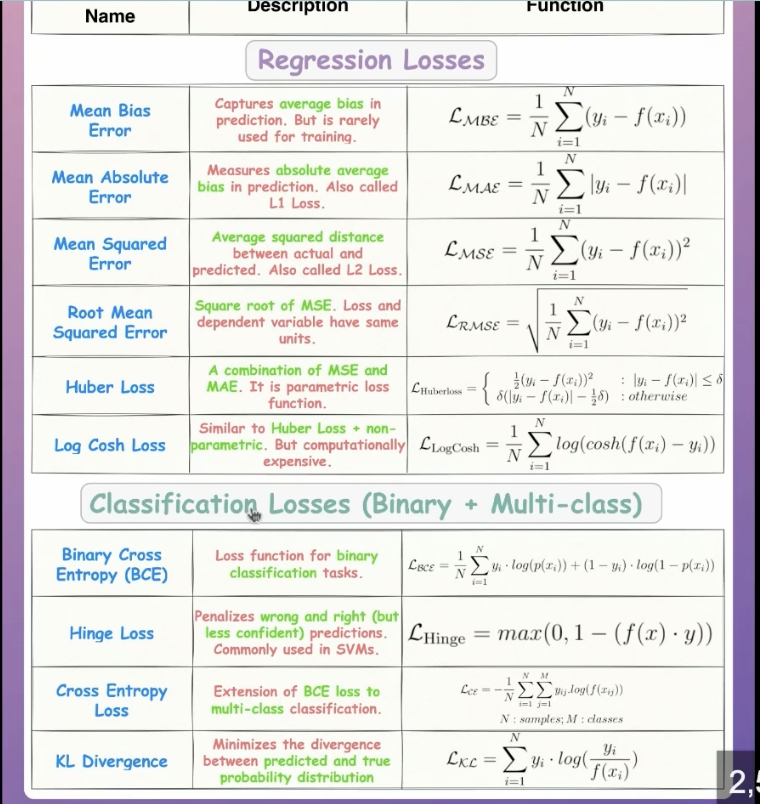

## How to measure LLM prediction loss and Evaluate LLM output

1. We have inputs, predictions and target values

Consider example sentence ```"Every effort moves you"```

1. Suppose if each word is atoken then there are 4 tokens

2. output we get is a 

Token1  ------------------- (vocab_size)

Token2  ------------------- (vocab_size)

Token3  ------------------- (vocab_size)

Token4  ------------------- (vocab_size)

That is num_tokens * vocab_size

3. Here 4 next word predictions are happening - 

```
Every - 
Every effort - 
Every effort moves - 
Every effort moves you - 
```

4. for each prediction task, we get a probability distribution for the next word among vocab_size


5. lengthn of logits - bathc_size * num_tokens * vocab_size

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
from gpt2_model import *

model = GPT2(config)
model.eval();  # Disable dropout during inference

In [2]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you Yingraised Ruff binddB interfere illegitimate HOMEDEPalt


In [3]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

In [4]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


In [5]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[23194],
         [14270],
         [27864]],

        [[31871],
         [ 3505],
         [12532]]])


In [6]:
print(f"EInput batch 1: {token_ids_to_text(inputs[0].flatten(), tokenizer)}")
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

EInput batch 1: every effort moves
Targets batch 1:  effort moves you
Outputs batch 1:  Jacksonville Legends Stuff


# Categorical Cross Entropy Loss

1. collect the probabilities from the outputs produced by the model at the required target groundtruth tokenids - These should be maximized

2. We take logarithms on the probabbilities

3. Find mean of these and apply negative to get negative log likelihood

4. We want this to be as low as possible

In [10]:
## We have logits as batch_size * num_tokens * vocab_size, convert those to probabilities by using softmax
logits_flattened = logits.reshape(inputs.shape[0]*inputs.shape[1], config.vocab_size)
log_probs = torch.log_softmax(logits_flattened, dim=-1)

## FlattenTarget outputs
targets_flattened = targets.reshape(targets.shape[0]* targets.shape[1], 1)

## Get probabilities at those indexes
out = log_probs.gather(1, targets_flattened).squeeze(1)

## Apply negative to convert into negative log likelihood
out_log_negative = torch.negative(out)


## Mean of this is Loss which we need to optimize
loss1 = torch.mean(out_log_negative)


In [11]:
import torch.nn.functional as F

loss2 = F.cross_entropy(
    logits_flattened,
    targets_flattened.squeeze(1)
)

In [12]:
loss1==loss2

tensor(True)

## Perplexity

- Measures how well the probability distribution preedicted by the model matche the actual distribution of words in the dataset

- More interpretable way of understanding model uncertainity in predicting next token

- Lower perplexity means better predictions

- Perplexity = torch.exp(loss)


Example - If perplexity is 48275 that means Model is roughly as uncertain as if it had to chose the next token randomly from about 48275 tokens in the vocabulary

In [13]:
perplexity = torch.exp(loss1)

In [14]:
perplexity

tensor(50284.6289)